In [2]:
import os
import pandas as pd
import numpy as np

def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None


In [2]:
import random
import matplotlib.pyplot as plt

def visualize_mean_all_columns(start, end):
    
    dfs = []
    
    for i in range(start, end):
        df = load_scenario_data(i, base_path=r"D:\LeakDB_full_data\Hanoi")
        
        if df is None:
            continue
        
        dfs.append(df)

    print("="*60)
    print("Plot of Leaks [0/1]")
    print("="*60)
        
    for df in dfs:
        plt.plot(df["Leaks"], color='blue', alpha=0.3, label='overlap')
        
    mean = pd.concat([df["Leaks"] for df in dfs], axis=1).mean(axis=1)
    plt.plot(mean, color='blue', linewidth=2, label='Mean')
        
    

Plot of Leaks [0/1]


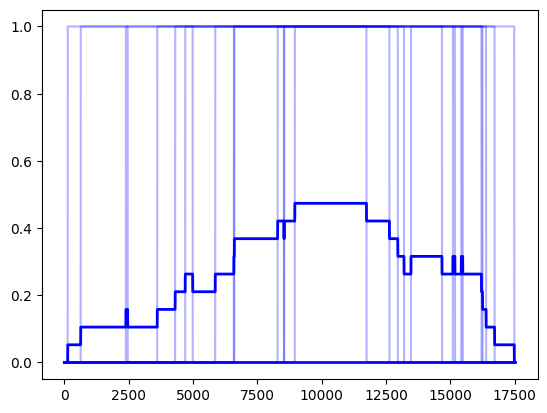

In [7]:
visualize_mean_all_columns(1, 20)

In [3]:
df_1 = load_scenario_data(1)
df_9 = load_scenario_data(9)

In [13]:
print("Scenario 1 leaks:")
print(df_1["Leaks"].value_counts())
print("Scenario 9 leaks:")
print(df_9["Leaks"].value_counts())


Scenario 1 leaks:
Leaks
0    17520
Name: count, dtype: int64
Scenario 9 leaks:
Leaks
0    9857
1    7663
Name: count, dtype: int64


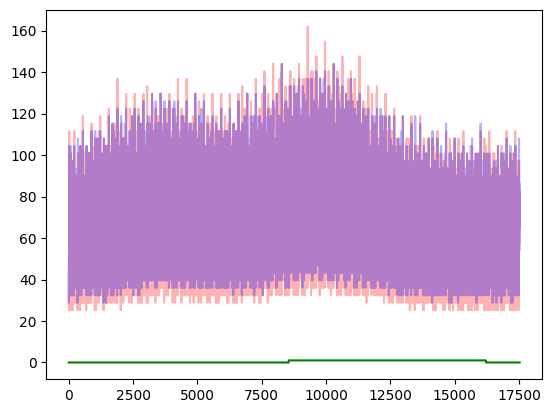

In [5]:
import matplotlib.pyplot as plt

plt.plot(df_1["demand_node_7"], color='red', label="Pressure at Node 7 for Scenario 1", alpha=0.3)
plt.plot(df_9["demand_node_7"], color='blue', label="Pressure at Node 7 for Scenario 9", alpha=0.3)

plt.plot(df_9["Leaks"], color='green', label="Leaks")

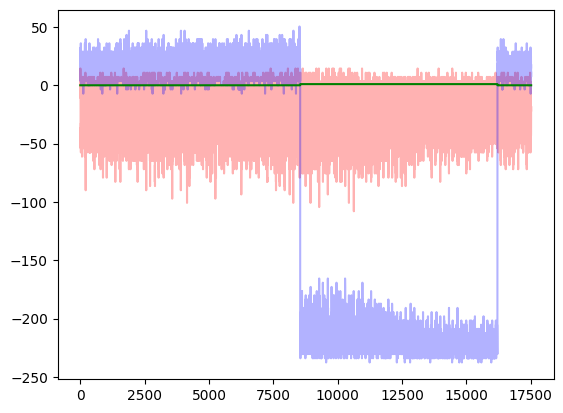

In [18]:
plt.plot(df_1["flow_link_7"], color='red', label="Flow at Node 7 for Scenario 1", alpha=0.3)
plt.plot(df_9["flow_link_7"], color='blue', label="Flow at Node 7 for Scenario 9", alpha=0.3)

plt.plot(df_9["Leaks"], color='green', label="Leaks")

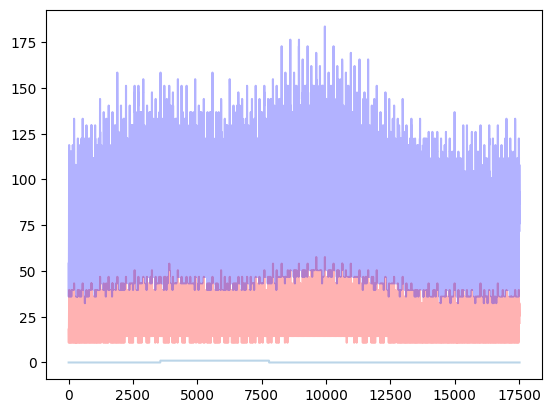

In [10]:
df_434 = load_scenario_data(434)
plt.plot(df_434["demand_node_25"], color='red', alpha=0.3)
plt.plot(df_434["demand_node_24"], color='blue', alpha=0.3)

plt.plot(df_434["Leaks"], alpha=0.3)